In [1]:
%pip install -q pystac-client planetary-computer odc-stac rasterio geopandas shapely scikit-learn matplotlib pandas xarray

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

import pystac_client
import planetary_computer
import odc.stac

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
)
from sklearn.model_selection import GroupShuffleSplit

np.random.seed(42)

print("Environment is ready.")

Note: you may need to restart the kernel to use updated packages.
Environment is ready.


In [2]:
# تهران و پیرامون
AOI = [51.30, 35.63, 51.47, 35.76]

STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

catalog = pystac_client.Client.open(
    STAC_URL,
    modifier=planetary_computer.sign_inplace,
)

print("AOI:", AOI)
print("Connected to Planetary Computer STAC.")

AOI: [51.3, 35.63, 51.47, 35.76]
Connected to Planetary Computer STAC.


In [3]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=AOI,
    datetime="2021-06-01/2021-09-30",
)

items = list(search.items())

if len(items) == 0:
    raise RuntimeError("No Sentinel-2 scenes were found for the selected AOI/date range.")

items_sorted = sorted(
    items,
    key=lambda item: item.properties.get("eo:cloud_cover", 100.0)
)

best_items = items_sorted[:3]

print(f"Found {len(items)} Sentinel-2 items.")
print("\nSelected scenes:")

for i, item in enumerate(best_items, 1):
    cloud = item.properties.get("eo:cloud_cover", np.nan)
    print(
        f"{i}. {item.id}\n"
        f"   date={item.datetime.date()} | cloud={cloud:.2f}%"
    )

Found 24 Sentinel-2 items.

Selected scenes:
1. S2B_MSIL2A_20210914T071619_R006_T39SWV_20210914T230716
   date=2021-09-14 | cloud=0.03%
2. S2A_MSIL2A_20210929T071701_R006_T39SWV_20210929T200018
   date=2021-09-29 | cloud=0.06%
3. S2A_MSIL2A_20210919T071621_R006_T39SWV_20210919T184938
   date=2021-09-19 | cloud=0.09%



Bandهای زیر استفاده می‌شوند:

- B02 = Blue
- B03 = Green
- B04 = Red
- B08 = Near Infrared
- B11 = SWIR-1
- B12 = SWIR-2
- SCL = Scene Classification Layer


SCL برای حذف Cloud، Cloud Shadow، Snow و NoData استفاده می‌شود.

In [4]:
spectral_bands = ["B02", "B03", "B04", "B08", "B11", "B12"]

s2 = odc.stac.load(
    best_items,
    bands=spectral_bands + ["SCL"],
    bbox=AOI,
    crs="utm",
    resolution=20,
    groupby="solar_day",
    resampling={
        "B02": "bilinear",
        "B03": "bilinear",
        "B04": "bilinear",
        "B08": "bilinear",
        "B11": "bilinear",
        "B12": "bilinear",
        "SCL": "nearest",
    },
)

geobox = s2.odc.geobox

print(s2)
print("\nCRS:", geobox.crs)
print("Raster size:", geobox.shape)
print("Pixel size:", geobox.resolution)

<xarray.Dataset> Size: 47MB
Dimensions:      (y: 725, x: 772, time: 3)
Coordinates:
  * y            (y) float64 6kB 3.957e+06 3.957e+06 ... 3.943e+06 3.943e+06
  * x            (x) float64 6kB 5.271e+05 5.272e+05 ... 5.425e+05 5.426e+05
  * time         (time) datetime64[us] 24B 2021-09-14T07:16:19.024000 ... 202...
    spatial_ref  int32 4B 32639
Data variables:
    B02          (time, y, x) float32 7MB 1.192e+03 882.0 ... 1.142e+03 952.0
    B03          (time, y, x) float32 7MB 1.525e+03 1.052e+03 ... 1.314e+03
    B04          (time, y, x) float32 7MB 1.791e+03 1.249e+03 ... 1.714e+03
    B08          (time, y, x) float32 7MB 2.202e+03 1.51e+03 ... 2.456e+03
    B11          (time, y, x) float32 7MB 2.327e+03 2.021e+03 ... 2.658e+03
    B12          (time, y, x) float32 7MB 2.146e+03 1.919e+03 ... 2.204e+03
    SCL          (time, y, x) float32 7MB 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0 5.0

CRS: PROJCRS["WGS 84 / UTM zone 39N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 en

## سلول 5 — ماسک ابر و ساخت Median Composite

کلاس‌های معتبر SCL در این پروژه:

- 4 = Vegetation
- 5 = Not vegetated
- 6 = Water
- 7 = Unclassified

سایر کلاس‌های مربوط به ابر، سایه ابر، برف، اشباع و NoData حذف می‌شوند.

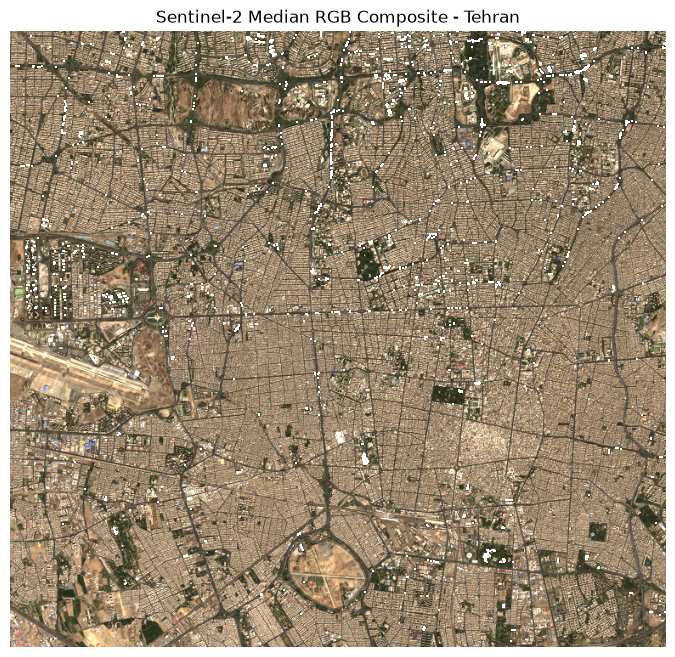

In [5]:
valid_scl = s2["SCL"].isin([4, 5, 6, 7])

reflectance = s2[spectral_bands].astype("float32") / 10000.0
reflectance = reflectance.where(valid_scl)

composite = reflectance.median(dim="time", skipna=True)

# حذف مقادیر فیزیکی نامعقول
for b in spectral_bands:
    composite[b] = composite[b].where(
        (composite[b] >= 0) & (composite[b] <= 1.2)
    )

# RGB برای نمایش
rgb = np.stack(
    [
        composite["B04"].values,
        composite["B03"].values,
        composite["B02"].values,
    ],
    axis=-1,
)

# Stretch ساده برای نمایش بهتر
rgb_display = np.clip(rgb / 0.30, 0, 1)

plt.figure(figsize=(9, 8))
plt.imshow(rgb_display)
plt.title("Sentinel-2 Median RGB Composite - Tehran")
plt.axis("off")
plt.show()

## سلول 6 — Feature Engineering و شاخص‌های طیفی

### NDVI
پوشش گیاهی:

\[
NDVI = \frac{NIR-Red}{NIR+Red}
\]

### NDWI
آب و رطوبت:

\[
NDWI = \frac{Green-NIR}{Green+NIR}
\]

### NDBI
مناطق ساخته‌شده:

\[
NDBI = \frac{SWIR-NIR}{SWIR+NIR}
\]

### BSI
Bare Soil Index برای زمین‌های بایر.

در مجموع مدل با **10 ویژگی** آموزش می‌بیند.

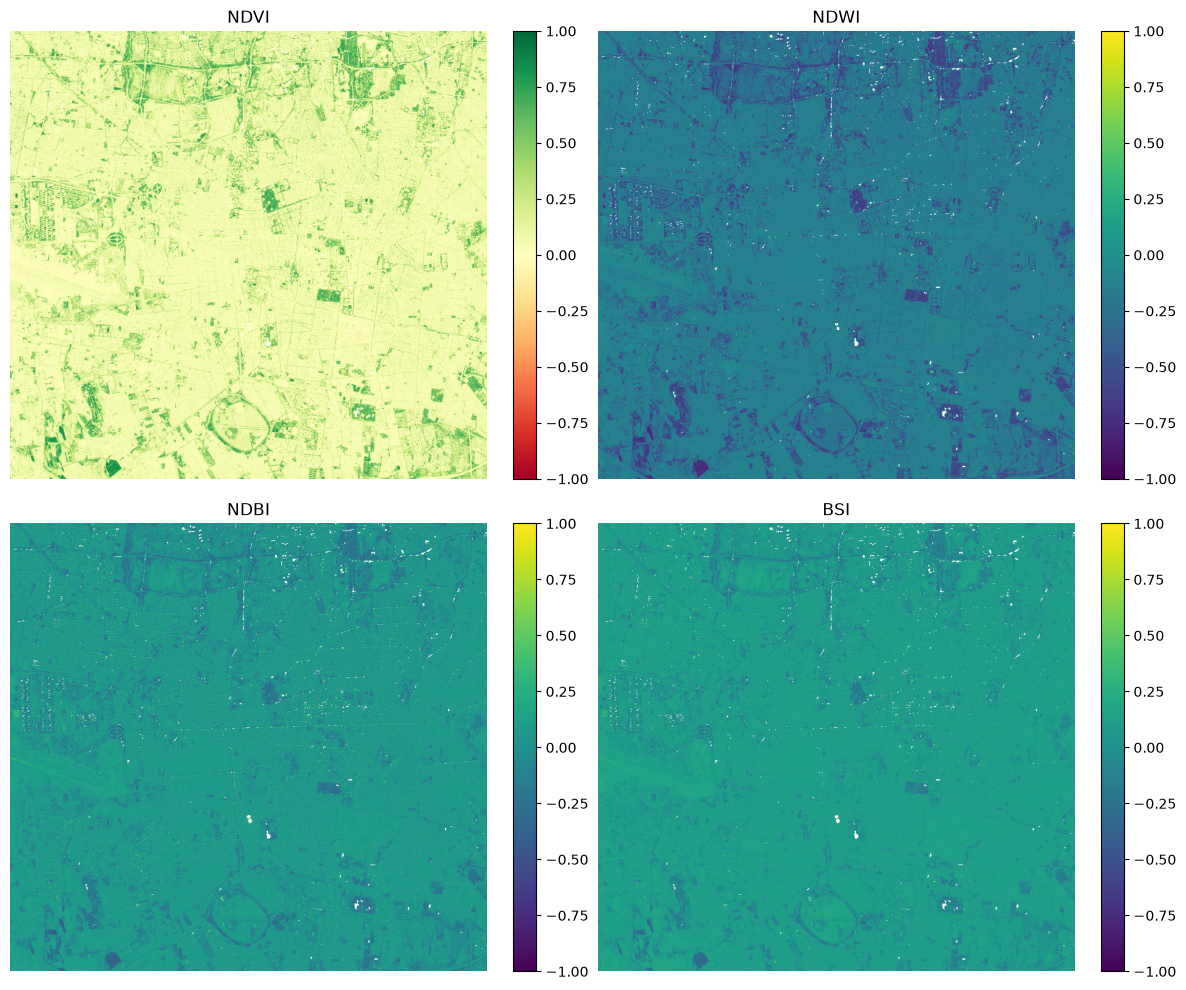

In [6]:
eps = 1e-6

B02 = composite["B02"]
B03 = composite["B03"]
B04 = composite["B04"]
B08 = composite["B08"]
B11 = composite["B11"]
B12 = composite["B12"]

NDVI = (B08 - B04) / (B08 + B04 + eps)
NDWI = (B03 - B08) / (B03 + B08 + eps)
NDBI = (B11 - B08) / (B11 + B08 + eps)

BSI = (
    (B11 + B04) - (B08 + B02)
) / (
    (B11 + B04) + (B08 + B02) + eps
)

indices = {
    "NDVI": NDVI,
    "NDWI": NDWI,
    "NDBI": NDBI,
    "BSI": BSI,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, da) in zip(axes.ravel(), indices.items()):
    im = ax.imshow(
        da.values,
        cmap="RdYlGn" if name == "NDVI" else "viridis",
        vmin=-1,
        vmax=1,
    )
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

In [7]:
wc_search = catalog.search(
    collections=["esa-worldcover"],
    bbox=AOI,
    datetime="2021-01-01/2021-12-31",
)

wc_items = list(wc_search.items())

if len(wc_items) == 0:
    raise RuntimeError("ESA WorldCover was not found for the selected AOI.")

worldcover_ds = odc.stac.load(
    wc_items,
    bands=["map"],
    like=s2,
    groupby="solar_day",
    resampling="nearest",
)

worldcover_raw = worldcover_ds["map"].isel(time=0).values.astype("uint8")

print("WorldCover items:", len(wc_items))
print("Raw class codes found:", np.unique(worldcover_raw))

WorldCover items: 1
Raw class codes found: [10 20 30 40 50 60 80]


## سلول 8 — تجمیع کلاس‌های WorldCover

برای اینکه پروژه آموزشی پایدارتر و تفسیرپذیرتر باشد، کلاس‌های WorldCover به 5 گروه اصلی تبدیل می‌شوند:

| کد مدل | کلاس |
|---|---|
| 1 | Vegetation |
| 2 | Cropland |
| 3 | Built-up |
| 4 | Bare/Sparse |
| 5 | Water/Wetland |

Tree، Shrubland و Grassland در Vegetation ادغام می‌شوند. Water و Wetland نیز در یک گروه قرار می‌گیرند.

کلاس‌هایی که تعداد Pixel کافی ندارند به‌صورت خودکار از آموزش حذف می‌شوند.

In [8]:
# WorldCover raw codes -> simplified classes
# 10 Tree, 20 Shrubland, 30 Grassland
# 40 Cropland, 50 Built-up, 60 Bare/Sparse
# 80 Water, 90 Wetland, 95 Mangroves

label_map = np.zeros_like(worldcover_raw, dtype=np.uint8)

label_map[np.isin(worldcover_raw, [10, 20, 30])] = 1
label_map[worldcover_raw == 40] = 2
label_map[worldcover_raw == 50] = 3
label_map[worldcover_raw == 60] = 4
label_map[np.isin(worldcover_raw, [80, 90, 95])] = 5

class_names = {
    1: "Vegetation",
    2: "Cropland",
    3: "Built-up",
    4: "Bare/Sparse",
    5: "Water/Wetland",
}

unique, counts = np.unique(label_map[label_map > 0], return_counts=True)

class_count_table = pd.DataFrame({
    "class_id": unique,
    "class_name": [class_names[int(x)] for x in unique],
    "pixels": counts,
})

display(class_count_table)

,class_id,class_name,pixels
0,1,Vegetation,53447
1,2,Cropland,6231
2,3,Built-up,490479
3,4,Bare/Sparse,9299
4,5,Water/Wetland,244


## سلول 9 — ساخت دیتاست آموزشی Pixel-based

Featureها:

- B02
- B03
- B04
- B08
- B11
- B12
- NDVI
- NDWI
- NDBI
- BSI

فقط Pixelهایی استفاده می‌شوند که:

1. تمام Featureهای آن‌ها معتبر باشند.
2. Label معتبر داشته باشند.
3. کلاس آن‌ها حداقل تعداد نمونه لازم را داشته باشد.

شماره سطر و ستون نیز ذخیره می‌شود تا در مرحله بعد بتوان Spatial Split انجام داد.

In [9]:
feature_names = spectral_bands + ["NDVI", "NDWI", "NDBI", "BSI"]

feature_arrays = [
    composite["B02"].values,
    composite["B03"].values,
    composite["B04"].values,
    composite["B08"].values,
    composite["B11"].values,
    composite["B12"].values,
    NDVI.values,
    NDWI.values,
    NDBI.values,
    BSI.values,
]

feature_stack = np.stack(feature_arrays, axis=0).astype("float32")

finite_mask = np.all(np.isfinite(feature_stack), axis=0)
valid_mask = finite_mask & (label_map > 0)

rows, cols = np.where(valid_mask)

X_all = feature_stack[:, valid_mask].T
y_all = label_map[valid_mask]

df = pd.DataFrame(X_all, columns=feature_names)
df["label"] = y_all
df["row"] = rows
df["col"] = cols

# حذف کلاس‌های بسیار کم‌نمونه
MIN_CLASS_PIXELS = 1000

counts = df["label"].value_counts()
keep_classes = counts[counts >= MIN_CLASS_PIXELS].index.tolist()

df = df[df["label"].isin(keep_classes)].reset_index(drop=True)

if df["label"].nunique() < 3:
    raise RuntimeError(
        "Fewer than 3 sufficiently represented classes remain. "
        "Try increasing the AOI."
    )

print("Number of valid pixels:", len(df))
print("Classes used:", [class_names[int(c)] for c in sorted(keep_classes)])

display(
    df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("class_id")
    .to_frame("pixels")
)

Number of valid pixels: 557575
Classes used: ['Vegetation', 'Cropland', 'Built-up', 'Bare/Sparse']


,pixels
class_id,
1,53204
2,6231
3,488914
4,9226


## سلول 10 — Spatial Holdout

در تقسیم تصادفی Pixelها، Pixelهای مجاور می‌توانند همزمان وارد Train و Test شوند و Accuracy غیرواقعی ایجاد کنند.

برای کاهش این مشکل، محدوده به **بلوک‌های مکانی تقریباً 2×2 کیلومتر** تقسیم می‌شود.

با تفکیک 20 متر:

- 100 Pixel × 100 Pixel ≈ 2 km × 2 km

سپس کل بلوک‌ها بین Train و Test تقسیم می‌شوند، نه Pixelهای منفرد.

In [10]:
BLOCK_SIZE = 100  # pixels ~ 2 km at 20 m resolution

df["block_row"] = df["row"] // BLOCK_SIZE
df["block_col"] = df["col"] // BLOCK_SIZE
df["block_id"] = (
    df["block_row"].astype(str) + "_" +
    df["block_col"].astype(str)
)

X = df[feature_names]
y = df["label"]
groups = df["block_id"]

# تلاش برای یک Spatial Split که همه کلاس‌ها را در Train و Test داشته باشد
target_classes = set(df["label"].unique())
split_found = False

for random_state in range(42, 82):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.25,
        random_state=random_state,
    )

    train_idx, test_idx = next(
        splitter.split(X, y, groups=groups)
    )

    train_classes = set(df.iloc[train_idx]["label"].unique())
    test_classes = set(df.iloc[test_idx]["label"].unique())

    if train_classes == target_classes and test_classes == target_classes:
        split_found = True
        break

if not split_found:
    print(
        "Warning: a spatial split containing every class in both sets "
        "was not found. The last spatial split will be used."
    )

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Spatial blocks:", df["block_id"].nunique())
print("Train pixels:", len(train_df))
print("Test pixels:", len(test_df))
print("Train blocks:", train_df["block_id"].nunique())
print("Test blocks:", test_df["block_id"].nunique())

Spatial blocks: 64
Train pixels: 420628
Test pixels: 136947
Train blocks: 48
Test blocks: 16


## سلول 11 — متوازن‌سازی نمونه‌ها و آموزش Random Forest

به دلیل عدم تعادل طبیعی کلاس‌های پوشش زمین، از هر کلاس حداکثر تعداد مشخصی نمونه برای Train انتخاب می‌شود.

ویژگی‌های مدل:

- 300 درخت
- `class_weight="balanced_subsample"`
- OOB Score
- محدودیت عمق برای کاهش Overfitting
- اجرای Parallel با `n_jobs=-1`

In [11]:
MAX_TRAIN_PER_CLASS = 6000
MAX_TEST_PER_CLASS = 10000

train_balanced = pd.concat(
    [
        g.sample(
            n=min(len(g), MAX_TRAIN_PER_CLASS),
            random_state=42
        )
        for _, g in train_df.groupby("label")
    ],
    ignore_index=True,
)

test_eval = pd.concat(
    [
        g.sample(
            n=min(len(g), MAX_TEST_PER_CLASS),
            random_state=42
        )
        for _, g in test_df.groupby("label")
    ],
    ignore_index=True,
)

X_train = train_balanced[feature_names]
y_train = train_balanced["label"]

X_test = test_eval[feature_names]
y_test = test_eval["label"]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=22,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("OOB score:", round(rf.oob_score_, 4))

Training samples: 23026
Testing samples: 24285
OOB score: 0.7312


## سلول 12 — ارزیابی مدل

فقط Accuracy کافی نیست. در این پروژه چهار نوع ارزیابی داریم:

- Overall Accuracy
- Balanced Accuracy
- Cohen's Kappa
- Precision / Recall / F1-score

Balanced Accuracy برای کلاس‌های نامتوازن مفیدتر از Accuracy ساده است.

In [12]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

labels_eval = sorted(np.unique(np.concatenate([y_test, y_pred])))
target_names = [class_names[int(c)] for c in labels_eval]

print(f"Overall Accuracy : {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Cohen's Kappa    : {kappa:.4f}")
print("\nClassification Report:\n")

report_text = classification_report(
    y_test,
    y_pred,
    labels=labels_eval,
    target_names=target_names,
    digits=4,
    zero_division=0,
)

print(report_text)

report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        labels=labels_eval,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T

report_df.to_csv("classification_report.csv")

Overall Accuracy : 0.7267
Balanced Accuracy: 0.7068
Cohen's Kappa    : 0.5954

Classification Report:

              precision    recall  f1-score   support

  Vegetation     0.8705    0.7152    0.7852     10000
    Cropland     0.3182    0.7353    0.4442      1205
    Built-up     0.8266    0.7760    0.8005     10000
 Bare/Sparse     0.4747    0.6006    0.5303      3080

    accuracy                         0.7267     24285
   macro avg     0.6225    0.7068    0.6401     24285
weighted avg     0.7748    0.7267    0.7423     24285



## سلول 13 — Confusion Matrix

Confusion Matrix نشان می‌دهد مدل کدام کلاس‌ها را با هم اشتباه گرفته است.

برای مثال اگر Built-up و Bare/Sparse زیاد با هم اشتباه شوند، می‌توان نتیجه گرفت که شباهت طیفی این دو کلاس برای مدل چالش‌برانگیز بوده است.

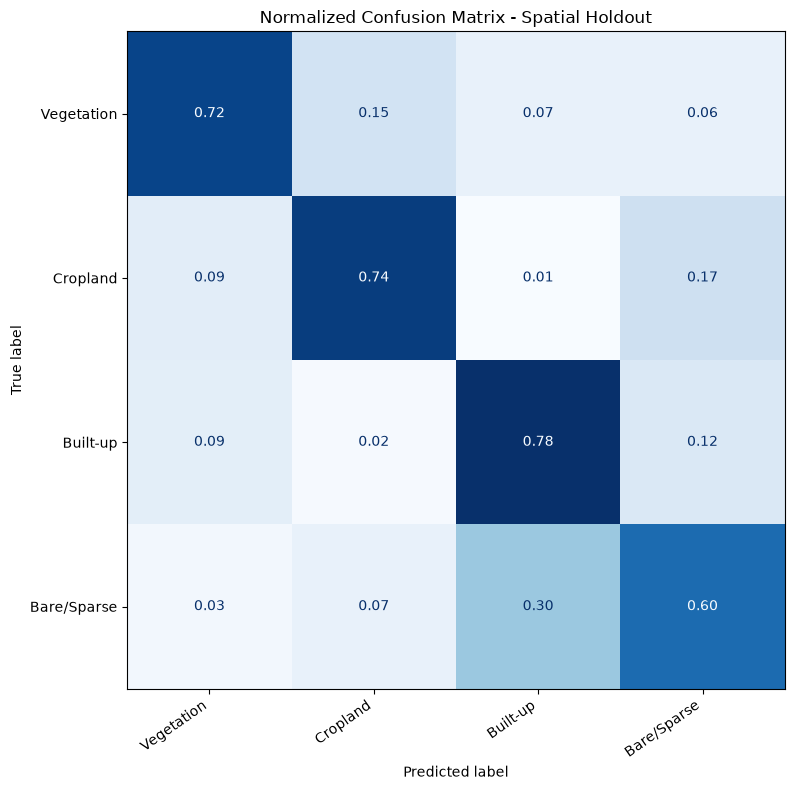

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_eval,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names,
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
)

plt.title("Normalized Confusion Matrix - Spatial Holdout")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## سلول 14 — Feature Importance

Random Forest امکان بررسی اهمیت نسبی Featureها را می‌دهد.

این بخش نشان می‌دهد مدل بیشتر به کدام Band یا شاخص طیفی وابسته بوده است.

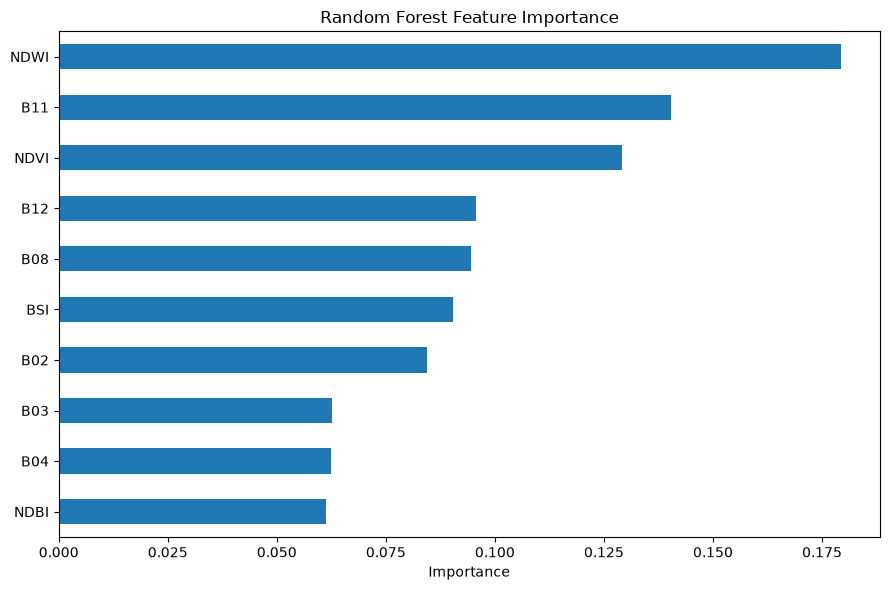

,importance
NDWI,0.179324
B11,0.140327
NDVI,0.129051
B12,0.095569
B08,0.094601
BSI,0.090415
B02,0.084364
B03,0.062671
B04,0.062483
NDBI,0.061195


In [14]:
importance = pd.Series(
    rf.feature_importances_,
    index=feature_names,
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

display(
    importance.sort_values(ascending=False)
    .rename("importance")
    .to_frame()
)

## سلول 15 — پیش‌بینی کل Raster و تولید نقشه Confidence

مدل روی تمام Pixelهای معتبر محدوده اجرا می‌شود.

دو Raster تولید می‌کنیم:

1. **Predicted Land Cover**
2. **Confidence**

Confidence برابر بیشترین احتمال کلاس در `predict_proba` است. مقدار نزدیک 1 یعنی مدل نسبت به پیش‌بینی خود مطمئن‌تر است.

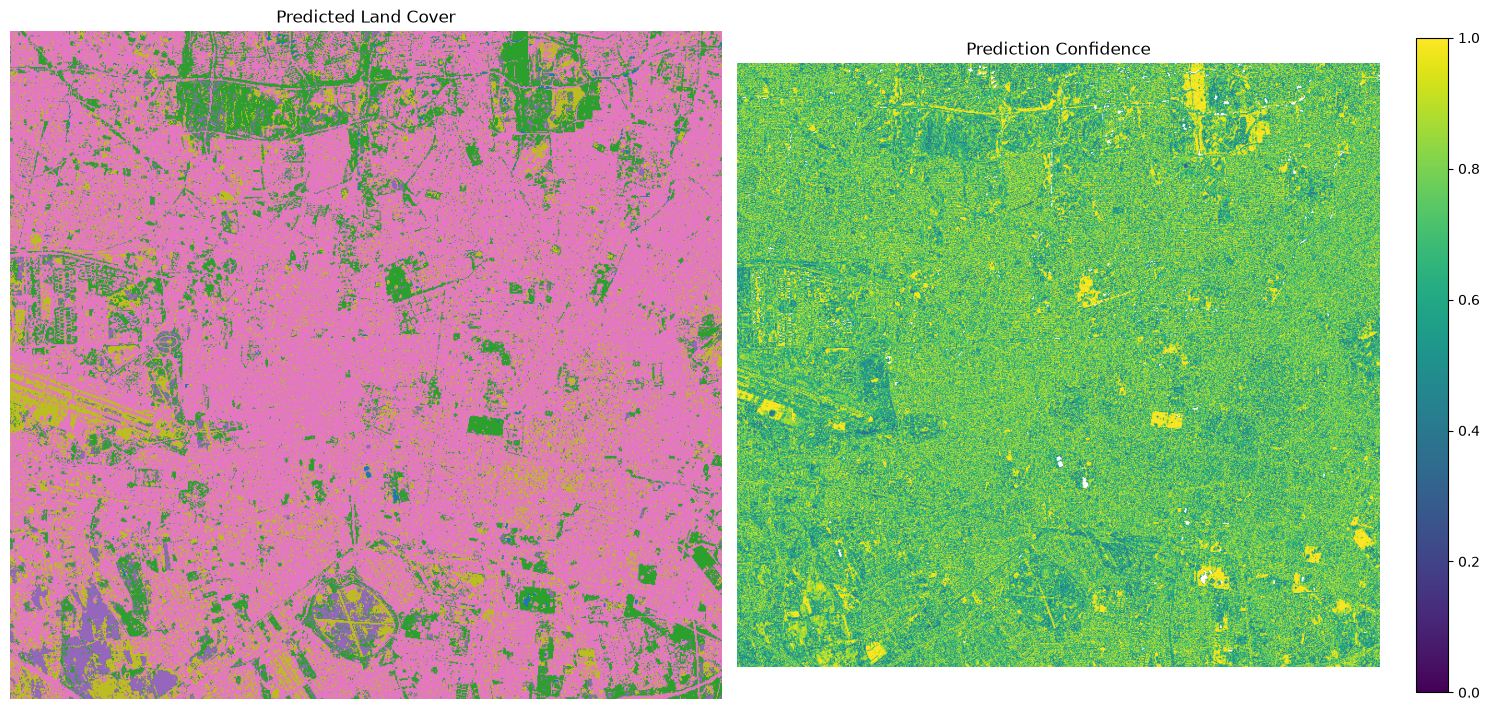

In [15]:
# فقط کلاس‌هایی که مدل در آموزش دیده است
class_mask = np.isin(label_map, rf.classes_)
full_valid_mask = finite_mask & class_mask

X_full = feature_stack[:, full_valid_mask].T

pred_full = rf.predict(X_full).astype("uint8")
proba_full = rf.predict_proba(X_full)
confidence_full = proba_full.max(axis=1).astype("float32")

pred_raster = np.zeros(label_map.shape, dtype="uint8")
conf_raster = np.full(label_map.shape, np.nan, dtype="float32")

pred_raster[full_valid_mask] = pred_full
conf_raster[full_valid_mask] = confidence_full

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im1 = axes[0].imshow(pred_raster, cmap="tab10", vmin=0, vmax=5)
axes[0].set_title("Predicted Land Cover")
axes[0].axis("off")

im2 = axes[1].imshow(conf_raster, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Prediction Confidence")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig("landcover_and_confidence.png", dpi=180, bbox_inches="tight")
plt.show()

## سلول 16 — ذخیره GeoTIFFهای نهایی

در این مرحله نقشه طبقه‌بندی و Confidence با اطلاعات مکانی صحیح ذخیره می‌شوند.

خروجی‌ها:

- `predicted_landcover_tehran.tif`
- `prediction_confidence_tehran.tif`

این فایل‌ها مستقیماً در QGIS یا ArcGIS قابل باز کردن هستند.

In [16]:
transform = geobox.transform
crs = str(geobox.crs)

height, width = pred_raster.shape

with rasterio.open(
    "predicted_landcover_tehran.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="uint8",
    crs=crs,
    transform=transform,
    nodata=0,
    compress="deflate",
) as dst:
    dst.write(pred_raster, 1)

with rasterio.open(
    "prediction_confidence_tehran.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs=crs,
    transform=transform,
    nodata=np.nan,
    compress="deflate",
) as dst:
    dst.write(conf_raster, 1)

print("Saved:")
print("- predicted_landcover_tehran.tif")
print("- prediction_confidence_tehran.tif")
print("- classification_report.csv")
print("- confusion_matrix.png")
print("- feature_importance.png")
print("- landcover_and_confidence.png")

Saved:
- predicted_landcover_tehran.tif
- prediction_confidence_tehran.tif
- classification_report.csv
- confusion_matrix.png
- feature_importance.png
- landcover_and_confidence.png


# تفسیر علمی پروژه

در این Notebook یک Workflow نسبتاً کامل GeoAI اجرا شد:

**STAC Search → Sentinel‑2 → Cloud Mask → Multi-temporal Composite → Spectral Indices → WorldCover Labels → Spatial Blocking → Random Forest → Accuracy Assessment → Explainability → Raster Prediction → GeoTIFF**

### چرا این پروژه از دو پروژه قبلی سطح بالاتری دارد؟

1. نوع داده Raster چندباندی است.
2. داده‌های چندزمانه استفاده شده‌اند.
3. Cloud Mask اعمال می‌شود.
4. Feature Engineering طیفی انجام می‌شود.
5. مدل Supervised است.
6. Ground Truth واقعی داریم.
7. Train/Test Split ماهیت مکانی دارد.
8. چند معیار ارزیابی استفاده می‌شود.
9. Feature Importance داریم.
10. Confidence Map تولید می‌شود.
11. خروجی نهایی GeoTIFF با Georeferencing واقعی است.

## پنج توسعه پیشنهادی

1. Random Forest را با **XGBoost یا LightGBM** مقایسه کنید.
2. Bandهای Red Edge یعنی B05، B06، B07 و B8A را اضافه کنید.
3. از چند فصل مختلف سال Feature بسازید و یک **Multi-season classifier** ایجاد کنید.
4. به‌جای یک Spatial Holdout، از **Spatial Cross Validation** با چند Fold استفاده کنید.
5. خروجی WorldCover را مستقیماً به 11 کلاس اصلی نگه دارید و عملکرد مدل را در یک AOI بزرگ‌تر بررسی کنید.

### نکته مهم

WorldCover در این پروژه به‌عنوان **Reference Label** استفاده شده است، نه حقیقت مطلق. بنابراین Accuracy مدل بیانگر میزان توافق مدل با برچسب مرجع WorldCover در محدوده و Sampling انتخاب‌شده است.